> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib pandas


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

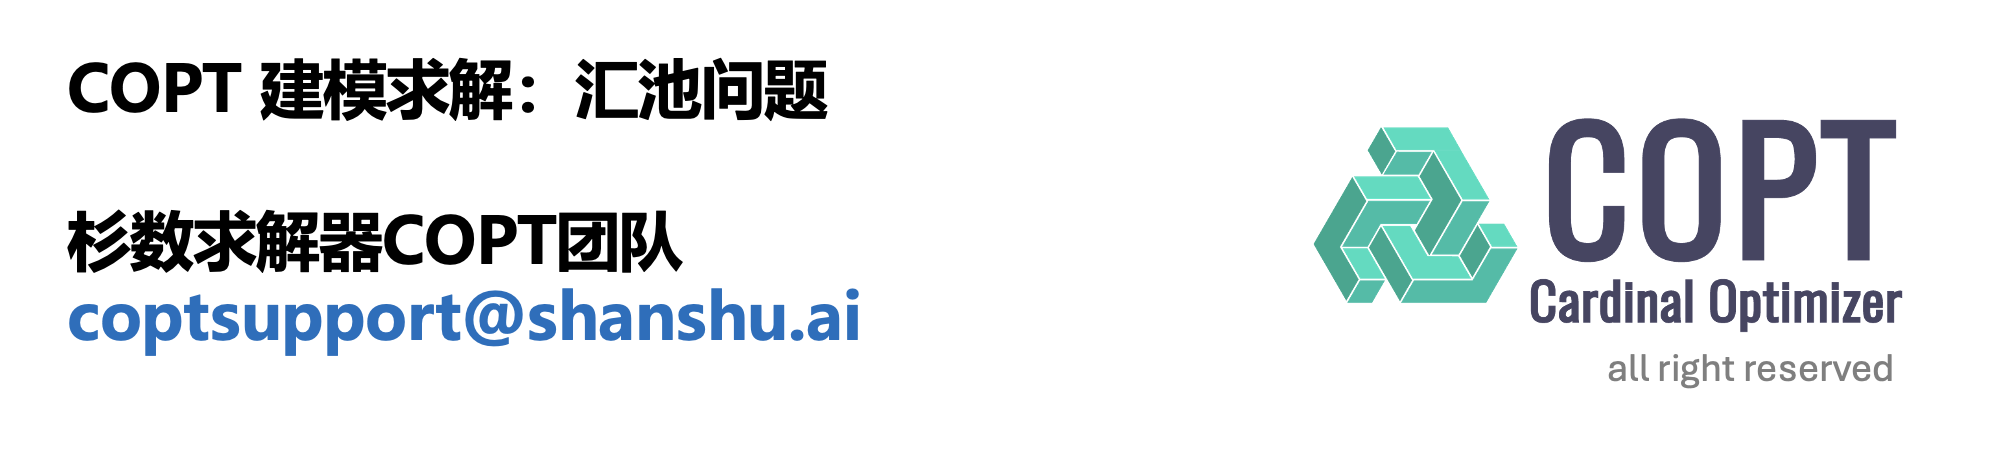

# 汇池问题代码实现
## 使用COPT建模求解汇池问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **添加数据模型**

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
   - **决策变量**：
     - $f_{ij}$：每条运输路径 $(i, j)$ 的运输流量，$f_{ij} \geq 0$；
     - $w_{i}$：从节点 $i$ 输出的天然气硫含量；
   - **目标函数**：最大化运营利润；
   - **约束条件**：
     - 从源点 $i$ 流出的天然气总量不大于其最大供应量 $ss_{i}$；
     - 终端 $i$ 接收到的天然气总量不小于其最小需求量 $td_{i}$；
     - 混合池不产生或消耗天然气，其流入量与流出量守恒，满足线性关系；
     - 线性混合模型质量守恒约束，从节点 $i$ 输出的天然气硫含量 $w_i$ 由输入该节点的所有天然气硫含量 $w_j, j \in NODE_i^{in}$ 按流量 $f_{ji}$ 加权平均决定。

5. **求解**

6. 查看、分析**结果**

## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT

## 添加模型数据

In [6]:
# 添加所有的节点
SOURCE = ["S1", "S2", "S3"]
POOL = ["P1", "P2"]
TERMINAL = ["T1", "T2", "T3", "T4", "T5"]
NODE = SOURCE + POOL + TERMINAL

# 添加节点之间的物流路径
source_to_pool = [(s, p) for s in SOURCE for p in POOL]
source_to_terminal = [(s, t) for s in SOURCE for t in TERMINAL]
pool_to_terminal = [(p, t) for p in POOL for t in TERMINAL]
ROUTE = source_to_pool + source_to_terminal + pool_to_terminal

# 添加供应、需求、质量指标、成本、价格数据
S_SUPPLY = {"S1":200, "S2":400, "S3":200}
S_QUALITY = {"S1":0.03, "S2":0.05, "S3":0.01}
S_COST = {"S1":5, "S2":3.5, "S3":8}
T_DEMAND = {"T1":100, "T2":80, "T3":160, "T4":90, "T5":120}
T_QUALITY = {"T1":0.038, "T2":0.03, "T3":0.04, "T4":0.02, "T5":0.015}
T_PRICE = {"T1":6.20, "T2":7.09, "T3":5.88, "T4":10.34, "T5":12.71}
R_COST = dict()
for r in ROUTE:
    if r in source_to_pool:
        R_COST[r] = 0.35
    elif r in source_to_terminal:
        R_COST[r] = 0.76
    else:
        R_COST[r] = 0.28

# 添加每个节点的上下游节点
NODE_IN = dict()
NODE_OUT = dict()
for i in NODE:
    if i in SOURCE:
        NODE_IN[i] = []
        NODE_OUT[i] = POOL + TERMINAL
    elif i in POOL:
        NODE_IN[i] = SOURCE
        NODE_OUT[i] = TERMINAL
    elif i in TERMINAL:
        NODE_IN[i] = POOL + SOURCE
        NODE_OUT[i] = []

## 创建求解环境和求解模型

In [8]:
env = cp.Envr()
model_1 = env.createModel("standard_pooling_problem")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量

- $f_{ij}$：每条运输路径 $(i, j)$ 的运输流量，$f_{ij} \geq 0$；
- $w_{i}$：从节点 $i$ 输出的天然气硫含量。

In [10]:
f = model_1.addVars(ROUTE, lb=0, ub=COPT.INFINITY, nameprefix="f")
w = model_1.addVars(NODE, lb=0, ub=COPT.INFINITY, nameprefix="w")

### 设置目标函数
模型的目标是最大化运营利润，其中利润 $=$ 售卖收入 $-$ 运输成本 $-$ 供应成本
$$
\max_{f_{ij},w_i}\quad \sum_{i \in TERMINAL} (tp_i \sum_{j \in NODE_i^{in}} f_{ji}) - \sum_{(i,j) \in ROUTE} f_{ij} rc_{ij} - \sum_{i \in SOURCE} (sc_i \sum_{j \in NODE_i^{out}} f_{ij})
$$

In [12]:
sale_income = cp.quicksum(cp.quicksum(T_PRICE[i] * f[(j, i)] for j in NODE_IN[i]) for i in TERMINAL)
trans_cost = cp.quicksum(f[(i, j)] * R_COST[(i, j)] for (i, j) in ROUTE)
supply_cost = cp.quicksum(cp.quicksum(S_COST[i] * f[(i, j)] for j in NODE_OUT[i]) for i in SOURCE)

obj_model_1 = sale_income - trans_cost - supply_cost
model_1.setObjective(obj_model_1, cp.COPT.MAXIMIZE)

### 添加约束条件

1. 从源点 $i$ 流出的天然气总量不大于其最大供应量 $ss_{i}$：
$$
\sum_{j \in NODE_i^{out}} f_{ij} \leq ss_i ,\quad \forall i \in SOURCE
$$

In [15]:
model_1.addConstrs(cp.quicksum(f[(i, j)] for j in NODE_OUT[i]) <= S_SUPPLY[i] for i in SOURCE)

2. 终端 $i$ 接收到的天然气总量不小于其最小需求量 $td_{i}$：
$$
\sum_{j \in NODE_i^{in}} f_{ji} \geq td_i ,\quad \forall i \in TERMINAL
$$

In [17]:
model_1.addConstrs(cp.quicksum(f[(j, i)] for j in NODE_IN[i]) >= T_DEMAND[i] for i in TERMINAL)

3. 混合池不产生或消耗天然气，其流入量与流出量守恒，满足线性关系：
$$
\sum_{j \in NODE_i^{in}} f_{ji} = \sum_{j \in NODE_i^{out}} f_{ij}, \quad \forall i \in POOL
$$

In [19]:
model_1.addConstrs(cp.quicksum(f[j, i] for j in NODE_IN[i]) == cp.quicksum(f[i, j] for j in NODE_OUT[i]) for i in POOL)

4. 线性混合模型满足质量守恒，从节点 $i$ 输出的天然气硫含量 $w_i$ 由输入该节点的所有天然气硫含量 $w_j, j \in NODE_i^{in}$ 按流量 $f_{ji}$ 加权平均决定，这是一个双线性约束。
- 源点没有能够输入天然气的上游节点，且天然气硫含量是确定的，将源点天然气硫含量 $w_i$ 直接使用等式约束固定为其供应天然气的硫含量 $sq_i$：
$$
w_i = sq_i ,\quad \forall i \in SOURCE
$$

In [21]:
model_1.addConstrs(w[i] == S_QUALITY[i] for i in SOURCE)

- 混合池输出的天然气硫含量 $w_i$ 由所有输入的天然气流量和硫含量决定：
$$
\sum_{j \in NODE_i^{in}} f_{ji} w_j = w_i \sum_{j \in NODE_i^{in}} f_{ji} ,\quad \forall i \in POOL
$$

In [23]:
for i in POOL:
    model_1.addQConstr(cp.quicksum(f[(j, i)] * w[j] for j in NODE_IN[i]) == w[i] * cp.quicksum(f[(j, i)] for j in NODE_IN[i]))

- 终端接收到的天然气硫含量 $w_i$ 由所有输入的天然气流量和硫含量决定，且需要满足终端天然气硫含量的要求，不超过 $tq_i$：
$$
\sum_{j \in NODE_i^{in}} f_{ji} w_j = w_i \sum_{j \in NODE_i^{in}} f_{ji} ,\quad \forall i \in TERMINAL
$$
$$
w_i \leq tq_i ,\quad \forall i \in TERMINAL
$$

In [25]:
for i in TERMINAL:
    model_1.addQConstr(cp.quicksum(f[(j, i)] * w[j] for j in NODE_IN[i]) == w[i] * cp.quicksum(f[(j, i)] for j in NODE_IN[i]))
    model_1.addConstr(w[i] <= T_QUALITY[i])

## 求解

In [27]:
model_1.solve()

Model fingerprint: 3aeaae13

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a QCP problem

The original problem has:
    18 rows, 41 columns and 70 non-zero elements
    7 quadratic constraints

The problem is identified as a non-convex QCP, finding local optimum

The presolved problem has:
    18 rows, 41 columns and 70 non-zero elements
    7 quadratic constraints

Starting NLP barrier solver using 4 threads

Iter     Objective            Compl       Primal.Inf         Dual.Inf       Time
   0  -7.92999207e-01  +3.99830001e+02  +1.59949999e+02  +4.71750000e+00   0.00s
   1  -1.27888098e+00  +3.96119088e+02  +1.59908662e+02  +4.59369386e+00   0.01s
   2  -1.64452170e+01  +3.93415343e+02  +1.58250557e+02  +2.50889309e+01   0.01s
   3  -5.50483840e+01  +3.85285228e+02  +1.55471204e+02  +4.75323744e+01   0.02s

## 获取结果

In [29]:
if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):
    print("\nMaximum Profit:")
    print(" {0:.3e}".format(model_1.objval))
    print("\nVariable solution:")
    vars_model_3 = model_1.getVars()
    for var in vars_model_3:
        print(" {0} = {1:.3e}".format(var.name, var.x))
else:
  print("\n No solution available")


Maximum Profit:
 1.284e+03

Variable solution:
 f(S1,P1) = 1.455e+02
 f(S1,P2) = 5.454e+01
 f(S2,P1) = 1.698e+02
 f(S2,P2) = 1.828e-01
 f(S3,P1) = 6.274e+00
 f(S3,P2) = 1.937e+02
 f(S1,T1) = 0.000e+00
 f(S1,T2) = 0.000e+00
 f(S1,T3) = 0.000e+00
 f(S1,T4) = 0.000e+00
 f(S1,T5) = 0.000e+00
 f(S2,T1) = 0.000e+00
 f(S2,T2) = 0.000e+00
 f(S2,T3) = 0.000e+00
 f(S2,T4) = 0.000e+00
 f(S2,T5) = 0.000e+00
 f(S3,T1) = 0.000e+00
 f(S3,T2) = 0.000e+00
 f(S3,T3) = 0.000e+00
 f(S3,T4) = 0.000e+00
 f(S3,T5) = 0.000e+00
 f(P1,T1) = 9.157e+01
 f(P1,T2) = 4.840e+01
 f(P1,T3) = 1.589e+02
 f(P1,T4) = 1.950e+01
 f(P1,T5) = 3.154e+00
 f(P2,T1) = 8.434e+00
 f(P2,T2) = 3.160e+01
 f(P2,T3) = 1.069e+00
 f(P2,T4) = 7.050e+01
 f(P2,T5) = 1.368e+02
 w(S1) = 3.000e-02
 w(S2) = 5.000e-02
 w(S3) = 1.000e-02
 w(P1) = 4.017e-02
 w(P2) = 1.442e-02
 w(T1) = 3.800e-02
 w(T2) = 3.000e-02
 w(T3) = 4.000e-02
 w(T4) = 2.000e-02
 w(T5) = 1.500e-02


为更加直观理解模型输出结果，将路径‑流量-成本结果汇总为表格，并绘制绘制网络图对实际使用路径及流量进行可视化展示。其中，网络图内箭头宽度与该路径的流量呈正比关系，以此区分不同路径的流量规模。

In [31]:
# 打印求解结果
if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):
    # 提取流量变量
    flow_value = {(i, j): float(f[(i, j)].x) for (i, j) in ROUTE}

    # 计算销售收入、运输成本和供应成本
    sale_income_value = sum(
        T_PRICE[t] * sum(flow_value[(j, t)] for j in NODE_IN[t])
        for t in TERMINAL
    )
    trans_cost_value = sum(flow_value[r] * R_COST[r] for r in ROUTE)
    supply_cost_value = sum(
        S_COST[s] * sum(flow_value[(s, j)] for j in NODE_OUT[s])
        for s in SOURCE
    )
    profit_value = sale_income_value - trans_cost_value - supply_cost_value

    print("-" * 68)
    print(f"最大利润：{profit_value:,.4f}")
    print(f"销售收入：{sale_income_value:,.4f}")
    print(f"运输成本：{trans_cost_value:,.4f}")
    print(f"供应成本：{supply_cost_value:,.4f}")
    print("-" * 68)
else:
    print("-" * 68)
    print(f"未获得可用解，当前求解状态为：{model_1.status}")
    print("\n" + "-" * 68)

# 打印有效路径流量表
import pandas as pd

if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):
    # 提取流量大于 0 的有效路径，按照序号从 0 到 15 递增
    route_df = pd.DataFrame([
        {
            "上游节点": i,
            "下游节点": j,
            "路径类型": (
                "源点→混合池" if i in SOURCE and j in POOL
                else "源点→终端" if i in SOURCE and j in TERMINAL
                else "混合池→终端"
            ),
            "运输流量": flow_value[(i, j)],
            "单位运输成本": R_COST[(i, j)],
            "运输成本": flow_value[(i, j)] * R_COST[(i, j)],
        }
        for (i, j) in ROUTE if flow_value[(i, j)] > 1e-6
    ])

    print("\n有效路径流量表：")
    display(route_df.style.format({
        "运输流量": "{:,.2f}",
        "单位运输成本": "{:,.2f}",
        "运输成本": "{:,.2f}",
    }))

--------------------------------------------------------------------
最大利润：1,283.9014
销售收入：4,838.0021
运输成本：359.1001
供应成本：3,195.0006
--------------------------------------------------------------------

有效路径流量表：


,上游节点,下游节点,路径类型,运输流量,单位运输成本,运输成本
0,S1,P1,源点→混合池,145.46,0.35,50.91
1,S1,P2,源点→混合池,54.54,0.35,19.09
2,S2,P1,源点→混合池,169.82,0.35,59.44
3,S2,P2,源点→混合池,0.18,0.35,0.06
4,S3,P1,源点→混合池,6.27,0.35,2.20
5,S3,P2,源点→混合池,193.73,0.35,67.80
6,P1,T1,混合池→终端,91.57,0.28,25.64
7,P1,T2,混合池→终端,48.40,0.28,13.55
8,P1,T3,混合池→终端,158.93,0.28,44.50
9,P1,T4,混合池→终端,19.50,0.28,5.46


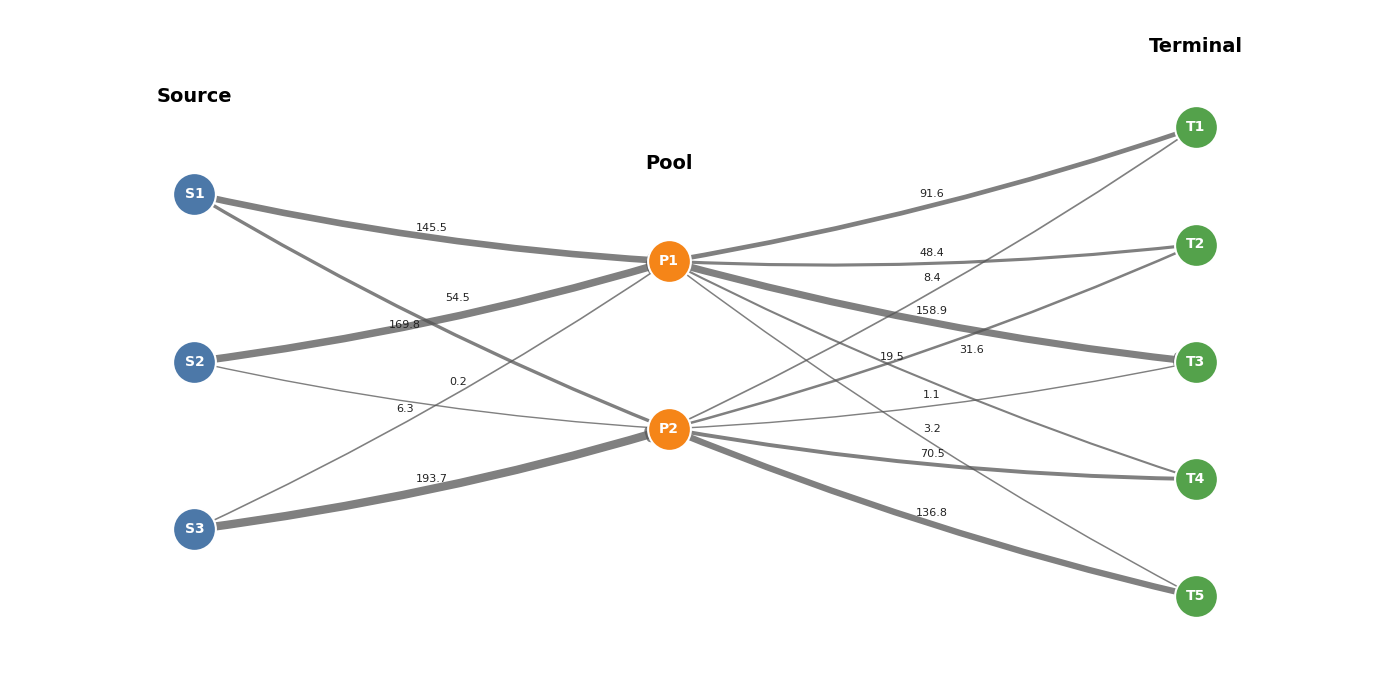

In [32]:
# 绘制汇池网络流量图
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):

    positions = {
        "S1": (0, 2.2), "S2": (0, 1.2), "S3": (0, 0.2),
        "P1": (1.8, 1.8), "P2": (1.8, 0.8),
        "T1": (3.8, 2.6), "T2": (3.8, 1.9), "T3": (3.8, 1.2),
        "T4": (3.8, 0.5), "T5": (3.8, -0.2),
    }
    
    # 针对容易重叠的交叉路径，手动设置文本的微小偏移量 (dx, dy)
    text_offsets = {
        ("S1", "P2"): (0.1, 0.08),   # 向右上方微调
        ("S2", "P1"): (-0.1, -0.08), # 向左下方微调
        ("S2", "P2"): (0.1, 0.08),   
        ("S3", "P1"): (-0.1, -0.08),
        ("P1", "T4"): (-0.15, 0.08),
        ("P2", "T2"): (0.15, -0.08)
    }
    
    colors = {**{s: "#4C78A8" for s in SOURCE}, **{p: "#F58518" for p in POOL}, **{t: "#54A24B" for t in TERMINAL}}
    fig, ax = plt.subplots(figsize=(14, 7))
    
    max_flow = max(flow_value.values()) if flow_value else 1.0
    
    # 绘制带箭头的边
    for (i, j), value in flow_value.items():
        if value <= 1e-6:
            continue
        x1, y1 = positions[i]
        x2, y2 = positions[j]
        arrow = FancyArrowPatch(
            (x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=14,
            linewidth=1.0 + 5.0 * value / max_flow, color="#555555", alpha=0.75,
            connectionstyle="arc3,rad=0.04",
        )
        ax.add_patch(arrow)
        
        # 计算原本的中心点位置
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        # 获取该路径的偏移量，如果没有特别定义则为 (0, 0)
        dx, dy = text_offsets.get((i, j), (0, 0))
        
        # 加上偏移量绘制文本，并设置居中对齐
        ax.text(mid_x + dx, mid_y + dy, f"{value:.1f}", fontsize=8, color="#222222", ha="center", va="center")
        
    # 绘制节点
    for node, (x_pos, y_pos) in positions.items():
        ax.scatter(x_pos, y_pos, s=950, color=colors[node], edgecolor="white", linewidth=1.5, zorder=3)
        ax.text(x_pos, y_pos, node, ha="center", va="center", color="white", weight="bold", zorder=4)
        
    # 添加标识和标题
    ax.text(0, 2.75, "Source", ha="center", fontsize=14, weight="bold")
    ax.text(1.8, 2.35, "Pool", ha="center", fontsize=14, weight="bold")
    ax.text(3.8, 3.05, "Terminal", ha="center", fontsize=14, weight="bold")
    ax.set_xlim(-0.7, 4.5)
    ax.set_ylim(-0.7, 3.3)
    ax.axis("off")
    
    plt.tight_layout()
    plt.show()